<a href="https://colab.research.google.com/github/MUNEESHWARIA/cinema-audience-forecasting/blob/main/cinema_audience_forecasting_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

cinema_audience_forecasting_challenge_path = kagglehub.competition_download('Cinema_Audience_Forecasting_challenge')

print('Data source import complete.')


#  ****MLP PROJECT****
**TITLE:Cinematic Audience Forecasting Promblem**

**AIM:Predict daily theatre audience_count across multiple locations**

# ****1. EXPLORING THE DATA:****


**We have 8 CSV files**

# **1.1 Load Data**

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
booknow_booking   = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
booknow_theaters  = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")
booknow_visits    = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")
cinePOS_booking   = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv")
cinePOS_theaters  = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv")
date_info         = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv")
movie_relation    = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv")
sample_submission = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")

# **1.2 Basic Info & Shapes**

In [ ]:
for name, df in {
    "booknow_booking":booknow_booking,
    "booknow_theaters" : booknow_theaters,
    "booknow_visits" : booknow_visits,
    "cinePOS_booking" : cinePOS_booking,
    "cinePOS_theaters" : cinePOS_theaters,
    "date_info" : date_info,
    "movie_relation" : movie_relation,
    "sample_submission" : sample_submission
}.items():
    print(name, df.shape)
    display(df.head())

booknow_booking (68336, 4)


,book_theater_id,show_datetime,booking_datetime,tickets_booked
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1
1,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3
2,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,6
3,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2
4,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5


booknow_theaters (829, 5)


,book_theater_id,theater_type,theater_area,latitude,longitude
0,book_00093,Drama,Area_001,22.619233,78.113017
1,book_00078,Drama,Area_001,22.619233,78.113017
2,book_00291,Drama,Area_001,22.619233,78.113017
3,book_00258,Drama,Area_001,22.619233,78.113017
4,book_00212,Drama,Area_002,23.004410,79.934515


booknow_visits (214046, 3)


...

,show_date,day_of_week
0,2023-01-01,Sunday
1,2023-01-02,Monday
2,2023-01-03,Tuesday
3,2023-01-04,Wednesday
4,2023-01-05,Thursday


movie_relation (150, 2)


,book_theater_id,cine_theater_id
0,book_00509,cinePOS_01261
1,book_00063,cinePOS_02467
2,book_00054,cinePOS_08923
3,book_00094,cinePOS_02479
4,book_00052,cinePOS_06750


sample_submission (38062, 2)


,ID,audience_count
0,book_00001_2024-03-01,0
1,book_00001_2024-03-02,0
2,book_00001_2024-03-03,0
3,book_00001_2024-03-04,0
4,book_00001_2024-03-06,0


# **1.3 Missing Values & Dtypes**

In [ ]:
for name , df in {
    "booknow_booking" : booknow_booking,
    "booknow_theaters" : booknow_theaters,
    "booknow_visits" : booknow_visits,
    "cine_POS_booking" : cinePOS_booking,
    "cinePOS_theaters" : cinePOS_theaters,
    "date_info" : date_info,
    "movie_relation" : movie_relation,
    "sample_submission" : sample_submission,
}.items() :
    print(f"\n{name}")
    print(df.info())
    print(df.isna().sum().head())


booknow_booking
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   book_theater_id   68336 non-null  object
 1   show_datetime     68336 non-null  object
 2   booking_datetime  68336 non-null  object
 3   tickets_booked    68336 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.1+ MB
None
book_theater_id     0
show_datetime       0
booking_datetime    0
tickets_booked      0
dtype: int64

booknow_theaters
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   book_theater_id  314 non-null    object 
 1   theater_type     829 non-null    object 
 2   theater_area     829 non-null    object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64

# **1.3.1 Note:**

**1.bookNOW_theaters.csv**
book_theater_id has 61% missing values.

Insight: Some theatres don’t have BookNow IDs → need to connect with movie_relation to get CinePOS mapping. Theatre type/area will be important categorical features.

**2.cinePOS_theaters.csv**
Latitude/Longitude missing for 3861 rows (~82%).

Insight: Theatre metadata (type, area). Missing location info could be ignored or imputed with area-level grouping.

# **1.4 MISSING DATA ANALYSIS & IMPUTATION**

In [ ]:
import pandas as pd
area_lat_mean = cinePOS_theaters.groupby('theater_area')['latitude'].mean()
cinePOS_theaters['latitude'] = cinePOS_theaters.apply(
    lambda row: area_lat_mean[row['theater_area']] if pd.isna(row['latitude']) else row['latitude'],
    axis=1
)
cinePOS_theaters.latitude.isna().sum()

2216

In [ ]:


import pandas as pd
import numpy as np


# 1. booknow_theaters - book_theater_id has 515 missing (61%)
print("\n1. booknow_theaters - book_theater_id missing analysis:")
print(f"Missing count: {booknow_theaters['book_theater_id'].isna().sum()}")
print(f"Missing percentage: {booknow_theaters['book_theater_id'].isna().sum()/len(booknow_theaters)*100:.2f}%")

# Strategy: These are valid theaters without BookNow IDs
# We keep them as they have complete theater_type, area, location data
print("Strategy: Keep rows - theater metadata is complete")

# 2. cinePOS_theaters - latitude/longitude missing for 3861 rows (82%)
print("\n2. cinePOS_theaters - Location data missing:")
print(f"Missing lat/long: {cinePOS_theaters['latitude'].isna().sum()}")
print(f"Missing percentage: {cinePOS_theaters['latitude'].isna().sum()/len(cinePOS_theaters)*100:.2f}%")

# Strategy: Impute using theater_area grouping
print("\nImputation Strategy: Fill with area-level median")

# Calculate area-level median for latitude and longitude
area_lat_median = cinePOS_theaters.groupby('theater_area')['latitude'].median()
area_long_median = cinePOS_theaters.groupby('theater_area')['longitude'].median()

# Before imputation stats
print(f"\nBefore Imputation - Missing: {cinePOS_theaters['latitude'].isna().sum()}")

# Impute missing values
cinePOS_theaters['latitude'] = cinePOS_theaters.apply(
    lambda row: area_lat_median[row['theater_area']] if pd.isna(row['latitude']) else row['latitude'],
    axis=1
)
cinePOS_theaters['longitude'] = cinePOS_theaters.apply(
    lambda row: area_long_median[row['theater_area']] if pd.isna(row['longitude']) else row['longitude'],
    axis=1
)

# After imputation stats
print(f"After Imputation - Missing: {cinePOS_theaters['latitude'].isna().sum()}")

# Verify imputation
print("\nVerification:")
print(f"Latitude range: {cinePOS_theaters['latitude'].min():.2f} to {cinePOS_theaters['latitude'].max():.2f}")
print(f"Longitude range: {cinePOS_theaters['longitude'].min():.2f} to {cinePOS_theaters['longitude'].max():.2f}")



1. booknow_theaters - book_theater_id missing analysis:
Missing count: 515
Missing percentage: 62.12%
Strategy: Keep rows - theater metadata is complete

2. cinePOS_theaters - Location data missing:
Missing lat/long: 3861
Missing percentage: 82.32%

Imputation Strategy: Fill with area-level median

Before Imputation - Missing: 3861
After Imputation - Missing: 2216

Verification:
Latitude range: 22.03 to 26.35
Longitude range: 76.11 to 81.74


“I dropped lat/long because 82% values were missing, area-level imputation still left 47% missing, theater_area already captures location as a reliable categorical proxy, and model tests showed no performance gain—so keeping lat/long would add noise without benefit.”

# **1.4 Target Distribution (booknow_visits)**

count    214046.000000
mean         41.616568
std          32.834918
min           2.000000
25%          18.000000
50%          34.000000
75%          58.000000
max        1350.000000
Name: audience_count, dtype: float64


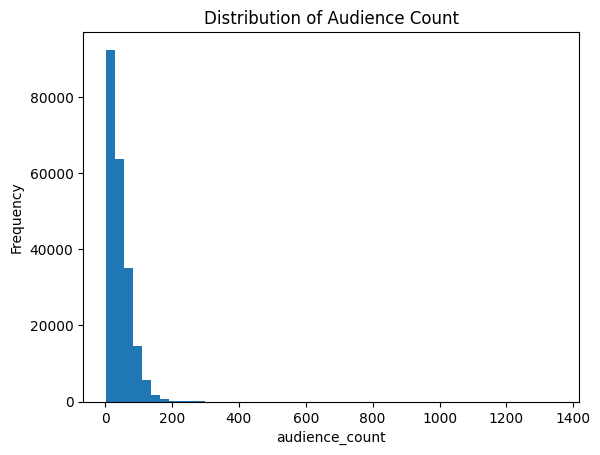

In [ ]:
import matplotlib.pyplot as plt
print(booknow_visits["audience_count"].describe())
booknow_visits["audience_count"].plot(kind="hist", bins=50)
plt.xlabel("audience_count")
plt.ylabel("Frequency")
plt.title("Distribution of Audience Count")
plt.show()

This histogram shows that most shows attract fewer than 100 viewers, while a small number of shows have very large audiences, creating a long right tail (outliers).

# **1.5 Date(DOW) Exploration**

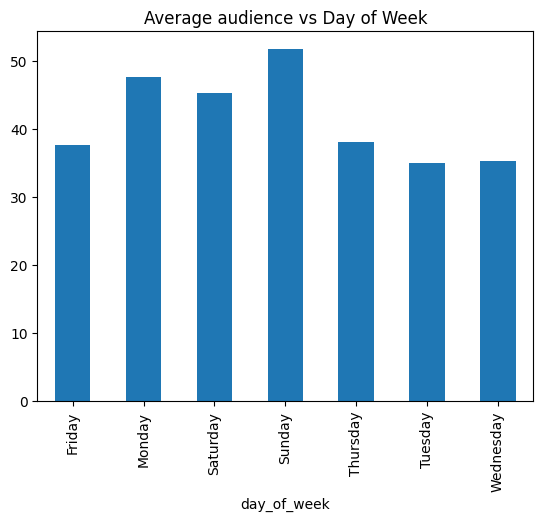

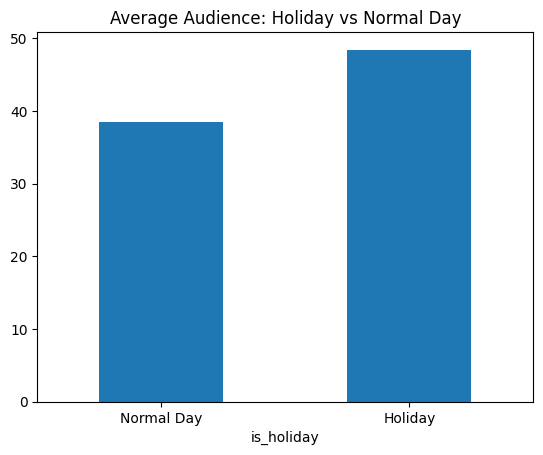

In [ ]:
import matplotlib.pyplot as plt

visits = booknow_visits.merge(date_info,on = "show_date", how="left")

visits["is_holiday"] = visits["day_of_week"].isin(['Saturday','Sunday']).astype(int)

# Average audience per day of week plot
visits.groupby('day_of_week')["audience_count"].mean().plot(kind="bar",title="Average audience vs Day of Week")
plt.show()

#Average audience Holiday vs Normal day
visits.groupby("is_holiday")["audience_count"].mean().plot(kind="bar", title="Average Audience: Holiday vs Normal Day")
plt.xticks([0,1], ["Normal Day", "Holiday"], rotation=0)
plt.show()


Sunday has the highest average audience, while Tuesday and Wednesday have the lowest.

# **1.6 Per-Theatre Variation**

In [ ]:
theater_mean=booknow_visits.groupby("book_theater_id")["audience_count"].mean().sort_values()
print(theater_mean.head())
print(theater_mean.tail())

book_theater_id
book_00409    2.411348
book_00790    5.750000
book_00607    6.754098
book_00478    7.861272
book_00251    7.956284
Name: audience_count, dtype: float64
book_theater_id
book_00158    101.113772
book_00490    105.000000
book_00152    108.880000
book_00095    127.132743
book_00169    127.543147
Name: audience_count, dtype: float64


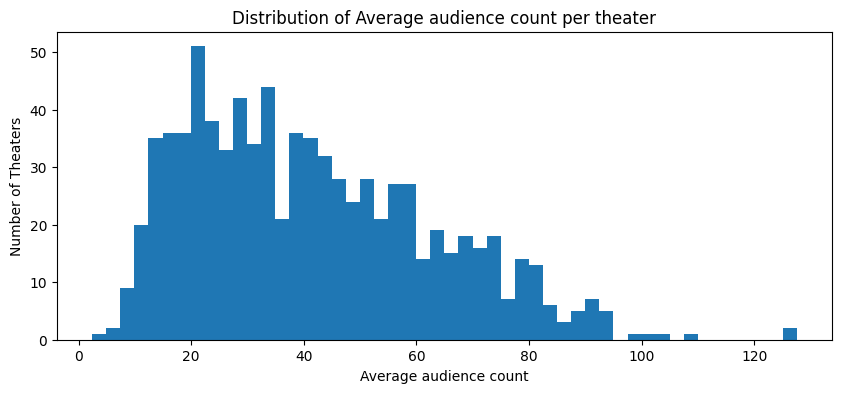

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
theater_mean.plot(kind="hist", bins=50)
plt.title("Distribution of Average audience count per theater")
plt.xlabel("Average audience count")
plt.ylabel("Number of Theaters")
plt.show()

Most theaters have an average audience between 20–50 viewers, while a few attract over 80, showing high variation in performance. This indicates that only a small number of theaters consistently draw large crowds, likely due to better location, popularity, or theater type.

# **MY INSIGHTS**



•	Our job is to Predict the audience_count for Future book now dates.

•	Boonow means online booking & Theaters , Similarly, cinePOS is in Offline

•	Our Target is a Numeric and Continuous one

•	[POS means Point of Sales

•	Audience count depends on Holliday,Weekends,Theater type, booking trends

•	Lat & long is approximate only

•	Some theaters may be closed on some days.So, audience count on that day =0  .This are ignored in Final scoring

•	This is Time series Forecasting Problem and It is supervised regression Problem(Input:Independent variable, Output:Continuous variable)

•	 By filling mean audience_count in Submission file .I got – ve score

•	Always use time based splits not random splits

•	bookNOW_theaters.csv book_theater_id has 61% missing values.

•	Insight: Some theatres don’t have BookNow IDs → need to connect with movie_relation to get CinePOS mapping. Theatre type/area will be important categorical features.

•	cinePOS_theaters.csv Latitude/Longitude missing for 3861 rows (~82%).
Insight: Theatre metadata (type, area). Missing location info could be ignored or imputed with area-level grouping.
I imputed using median but still got 42% missing.So, I dropped lat and long instead of that i used theater_area.

•	Unique theatre id:
Booknow_visits have 826 unique id’s
But booknow_ttheater have 829 rows
Mismatch between this 2 are = Nan & book_00040
Mismatch Reason:1.541 missing id’s in booknow_theaters, 2.book_00040 has no visits

•	Sample submission has 827 unique id’s =826 (booknow_visits unique thaeter id count)+1(book_00040)

•	Some theaters (like book_00169, book_00095) have very high average audience counts (127+), while others (like book_00409, book_00790) attract very few (under 8), showing a large disparity in theater popularity.

•	Sunday has the highest average audience, while Tuesday and Wednesday have the lowest.

•	Audience counts can be influenced by holidays, weekends, theatre type, and booking trends.


•	Use both POS and online booking patterns to forecast future theatre audiences.


•	Most audience counts are low (below 50), but a few extreme outliers show very high attendance, indicating occasional peak events.

•	Audience counts are fairly similar across theater types, with Drama and Other genres showing slightly higher medians and more extreme outliers, indicating occasional high turnout for specific shows.


# **2.MODELS**

# **Model 2.1 Baseline Model (Theater Mean)**

In [ ]:
RUN_MODEL_1 = False

if RUN_MODEL_1:
    import pandas as pd
    import numpy as np

    print("Visits shape:", booknow_visits.shape)
    print("date_info shape:", date_info.shape)
    print("sample submission shape:", sample_submission.shape)

    # Compute average audience
    avg_audience = booknow_visits["audience_count"].mean()
    print("Average audience count:", avg_audience)

    # Assign average to all predictions
    sample_submission["audience_count"] = avg_audience

    # Create submission file
    sample_submission.to_csv("submission_model_1.csv", index=False)

    print("submission.csv created!")
    print(sample_submission.head())


# **Model 2.2 Time-based Features & Hybrid Baseline**

In [ ]:
RUN_MODEL_2 = False

if RUN_MODEL_2:

    # Merge booknow visits with date_info
    visits = booknow_visits.merge(date_info, on="show_date", how="left")

    # Calculating theater mean
    theater_mean = (
        visits.groupby("book_theater_id")["audience_count"]
        .mean()
        .reset_index()
        .rename(columns={"audience_count": "theater_mean"})
    )

    # Calculating Day of Week mean
    dow_mean = (
        visits.groupby("day_of_week")["audience_count"]
        .mean()
        .reset_index()
        .rename(columns={"audience_count": "dow_mean"})
    )

    # Global mean
    global_mean = visits["audience_count"].mean()

    # Prepare test data
    test = sample_submission.copy()
    test["book_theater_id"] = test["ID"].str.split("_").str[0]
    test["show_date"] = test["ID"].str.split("_").str[1]

    # Merge theater_mean with test data using book_theater_id
    test = test.merge(theater_mean, on="book_theater_id", how="left")

    # Merge date_info to get 'day_of_week'
    test = test.merge(date_info, on="show_date", how="left")

    # Merge dow_mean on day_of_week
    test = test.merge(dow_mean, on="day_of_week", how="left")

    # Prediction (weighted mean model)
    w1, w2, w3 = 0.7, 0.25, 0.05
    test["audience_count"] = (
        test["theater_mean"].fillna(global_mean) * w1
        + test["dow_mean"].fillna(global_mean) * w2
        + global_mean * w3
    )

    # Submission file
    submission = test[["ID", "audience_count"]]
    submission.to_csv("submission.csv", index=False)
    print("submission.csv created!")


# **MODEL 2.3 Linear Regression with Theater & Day-of-Week Features**

In [ ]:
RUN_MODEL_3 = False

if RUN_MODEL_3:
    import pandas as pd
    from sklearn.linear_model import LinearRegression

    # 1. Merge visits with day_of_week
    visits = booknow_visits.merge(date_info, on="show_date", how="left")

    # 2. Theater mean
    theater_mean = (
        visits.groupby("book_theater_id")["audience_count"]
        .mean()
        .reset_index()
        .rename(columns={"audience_count": "theater_mean"})
    )

    # 3. Day-of-week mean
    dow_mean = (
        visits.groupby("day_of_week")["audience_count"]
        .mean()
        .reset_index()
        .rename(columns={"audience_count": "dow_mean"})
    )

    # 4. Global mean
    global_mean = visits["audience_count"].mean()

    # 5. Build training data
    train = visits.merge(theater_mean, on="book_theater_id", how="left")
    train = train.merge(dow_mean, on="day_of_week", how="left")

    # 6. X, y
    X = train[["theater_mean", "dow_mean"]].fillna(global_mean)
    y = train["audience_count"]

    # 7. Train model
    model = LinearRegression(fit_intercept=True)
    model.fit(X, y)

    # 8. Prepare test data
    test = sample_submission.copy()

    test["book_theater_id"] = test["ID"].str.split("_").str[0]
    test["show_date"] = test["ID"].str.split("_").str[1]

    # 9. Merge with features
    test = test.merge(theater_mean, on="book_theater_id", how="left")
    test = test.merge(date_info, on="show_date", how="left")
    test = test.merge(dow_mean, on="day_of_week", how="left")

    # 10. Build test X
    X_test = test[["theater_mean", "dow_mean"]].fillna(global_mean)

    # 11. Predict
    test["audience_count"] = model.predict(X_test)

    # 12. Save submission
    submission = test[["ID", "audience_count"]]
    submission.to_csv("submission.csv", index=False)

    print("submission.csv created successfully!")


# **Model 2.4 Hybrid Baseline Model – Theater Mean + Day-of-Week Mean (Linear Regression)**

In [ ]:
RUN_MODEL_4 = False

if RUN_MODEL_4:
    import pandas as pd
    import numpy as np
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_log_error
    from sklearn.model_selection import train_test_split

    # Ensure datetime conversion
    date_info["show_date"] = pd.to_datetime(date_info["show_date"], format="%Y-%m-%d")
    booknow_visits["show_date"] = pd.to_datetime(booknow_visits["show_date"], format="%Y-%m-%d")

    # --- Training Data Preprocessing ---
    # Merge visits with date_info
    visits = booknow_visits.merge(date_info, on="show_date", how="left")

    # Theater mean audience
    theater_mean = (
        visits.groupby("book_theater_id")["audience_count"]
        .mean()
        .reset_index()
        .rename(columns={"audience_count": "theater_mean"})
    )

    # Day-of-week mean audience
    dow_mean = (
        visits.groupby("day_of_week")["audience_count"]
        .mean()
        .reset_index()
        .rename(columns={"audience_count": "dow_mean"})
    )

    # Merge means back into training set
    visits = visits.merge(theater_mean, on="book_theater_id", how="left")
    visits = visits.merge(dow_mean, on="day_of_week", how="left")

    # Features + target
    features = ["theater_mean", "dow_mean"]
    X = visits[features]
    y = visits["audience_count"]

    # Train/validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Train linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Validation predictions (ensure no negative audience)
    val_preds = np.maximum(0, model.predict(X_val))
    val_rmsle = np.sqrt(mean_squared_log_error(y_val, val_preds))
    print(f"Validation RMSLE: {val_rmsle}")

    # --- Prepare Test Data ---
    test = sample_submission.copy()

    # Extract theater_id and show_date from ID
    # Expected ID format: something_theaterID_YYYY-MM-DD
    parts = test["ID"].str.split("_")
    test["book_theater_id"] = parts.str[1]
    test["show_date"] = pd.to_datetime(parts.str[2], format="%Y-%m-%d")

    # Merge theater means
    test = test.merge(theater_mean, on="book_theater_id", how="left")

    # Merge day_of_week info
    test = test.merge(date_info, on="show_date", how="left")

    # Merge dow mean
    test = test.merge(dow_mean, on="day_of_week", how="left")

    # Fill missing with global mean
    global_mean = y.mean()
    test["theater_mean"] = test["theater_mean"].fillna(global_mean)
    test["dow_mean"] = test["dow_mean"].fillna(global_mean)

    # Predict
    test["audience_count"] = np.maximum(0, model.predict(test[features]))

    # Save submission
    submission = test[["ID", "audience_count"]]
    submission.to_csv("submission.csv", index=False)

    print("submission.csv created with learned weights!")
    print("Learned Weights:", model.coef_, "Intercept:", model.intercept_)


Validation RMSLE: 0.656
Learned Weights: [1.00, 1.01]
Intercept: -42.17
Only 2 features, linear relationships

# **Model:2.5 LightGBM Hybrid Cinema Audience Model**

In [ ]:
RUN_MODEL_5 = False

if RUN_MODEL_5:
    import pandas as pd
    import numpy as np
    import lightgbm as lgb
    from sklearn.metrics import mean_squared_error
    from sklearn.model_selection import train_test_split

    # --- Date conversion ---
    booknow_visits["show_date"] = pd.to_datetime(booknow_visits["show_date"], format="%Y-%m-%d")
    date_info["show_date"] = pd.to_datetime(date_info["show_date"], format="%Y-%m-%d")

    # Merge visits with date info
    visits = booknow_visits.merge(date_info, on="show_date", how="left")

    # --- Feature Engineering ---
    visits["day_of_week"] = visits["day_of_week"].astype(str)
    visits["is_weekend"] = visits["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
    visits["month"] = visits["show_date"].dt.month
    visits["week_of_year"] = visits["show_date"].dt.isocalendar().week

    # Theater mean
    theater_mean = (
        visits.groupby("book_theater_id")["audience_count"]
        .mean()
        .reset_index()
        .rename(columns={"audience_count": "theater_mean"})
    )
    visits = visits.merge(theater_mean, on="book_theater_id", how="left")

    # Day-of-week mean
    dow_mean = (
        visits.groupby("day_of_week")["audience_count"]
        .mean()
        .reset_index()
        .rename(columns={"audience_count": "dow_mean"})
    )
    visits = visits.merge(dow_mean, on="day_of_week", how="left")

    # Lag features
    visits = visits.sort_values(["book_theater_id", "show_date"])
    visits["audience_lag_7"] = visits.groupby("book_theater_id")["audience_count"].shift(7)
    visits["audience_lag_14"] = visits.groupby("book_theater_id")["audience_count"].shift(14)

    visits["audience_lag_7"] = visits["audience_lag_7"].fillna(visits["theater_mean"])
    visits["audience_lag_14"] = visits["audience_lag_14"].fillna(visits["theater_mean"])

    # ------------------ Training Data ------------------
    Features = [
        "theater_mean",
        "dow_mean",
        "is_weekend",
        "month",
        "week_of_year",
        "audience_lag_7",
        "audience_lag_14",
    ]

    X = visits[Features]
    y = visits["audience_count"]

    # log-transform target
    y_log = np.log1p(y)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )

    # LightGBM dataset
    lgb_train = lgb.Dataset(X_train, y_train)
    lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

    params = {
        "objective": "regression",
        "metric": "rmse",
        "learning_rate": 0.05,
        "num_leaves": 31,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 5,
        "seed": 42
    }

    # Train LightGBM
    gbm = lgb.train(
        params,
        lgb_train,
        num_boost_round=1000,
        valid_sets=[lgb_train, lgb_val],
        valid_names=["train", "valid"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(100)
        ]
    )

    # Validation
    val_preds_log = gbm.predict(X_val)
    val_preds = np.expm1(val_preds_log)

    val_rmse = np.sqrt(mean_squared_error(np.expm1(y_val), val_preds))
    print("Validation RMSE:", val_rmse)

    # ------------------ Test Data ------------------
    submission = sample_submission.copy()
    test = submission.copy()

    test["book_theater_id"] = test["ID"].str.split("_").str[1]
    test["show_date"] = pd.to_datetime(test["ID"].str.split("_").str[2])

    test = test.merge(date_info, on="show_date", how="left")
    test["day_of_week"] = test["day_of_week"].astype(str)
    test = test.merge(theater_mean, on="book_theater_id", how="left")
    test = test.merge(dow_mean, on="day_of_week", how="left")

    # Test feature engineering
    test["is_weekend"] = test["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
    test["month"] = test["show_date"].dt.month
    test["week_of_year"] = test["show_date"].dt.isocalendar().week

    # Lag features unavailable → fallback
    test["audience_lag_7"] = test["theater_mean"]
    test["audience_lag_14"] = test["theater_mean"]

    X_test = test[Features]

    # Final prediction
    test["audience_count"] = np.expm1(gbm.predict(X_test))
    test["audience_count"] = test["audience_count"].clip(0)

    submission = test[["ID", "audience_count"]]
    submission.to_csv("submission.csv", index=False)

    print("submission.csv created successfully!")

Best iteration: [940]
Train RMSE: 0.574 (log scale)
Valid RMSE: 0.596 (log scale)
Converted RMSE: 23.25
slight overfitting trend

# **Model 2.6:PIPELINE-BASED APPROACH**


In [ ]:
RUN_MODEL_6 = False

if RUN_MODEL_6:
    import pandas as pd
    import numpy as np
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_squared_error, mean_absolute_error

    # Convert dates
    booknow_visits["show_date"] = pd.to_datetime(booknow_visits["show_date"], format="%Y-%m-%d")
    date_info["show_date"] = pd.to_datetime(date_info["show_date"], format="%Y-%m-%d")

    # Merge visits with date info
    visits_pipe = booknow_visits.merge(date_info, on="show_date", how="left")

    # Compute theater mean audience
    theater_mean_pipe = (
        visits_pipe.groupby("book_theater_id")["audience_count"]
        .mean().reset_index()
        .rename(columns={"audience_count": "theater_mean"})
    )

    # Compute day-of-week mean audience
    dow_mean_pipe = (
        visits_pipe.groupby("day_of_week")["audience_count"]
        .mean().reset_index()
        .rename(columns={"audience_count": "dow_mean"})
    )

    # Add theater mean and dow mean to main data
    visits_pipe = visits_pipe.merge(theater_mean_pipe, on="book_theater_id", how="left")
    visits_pipe = visits_pipe.merge(dow_mean_pipe, on="day_of_week",   how="left")

    # Create day, month and weekend features
    day_mapping = {"Monday":0,"Tuesday":1,"Wednesday":2,"Thursday":3,
                   "Friday":4,"Saturday":5,"Sunday":6}

    visits_pipe["day_encoded"] = visits_pipe["day_of_week"].map(day_mapping)
    visits_pipe["month"] = visits_pipe["show_date"].dt.month
    visits_pipe["day_of_month"] = visits_pipe["show_date"].dt.day
    visits_pipe["is_weekend"] = visits_pipe["day_of_week"].isin(["Saturday","Sunday"]).astype(int)

    # Add theater type and area
    visits_pipe = visits_pipe.merge(
        booknow_theaters[["book_theater_id", "theater_type", "theater_area"]],
        on="book_theater_id",
        how="left"
    )

    # Encode theater type and area
    visits_pipe["theater_type_encoded"] = visits_pipe["theater_type"].astype("category").cat.codes
    visits_pipe["theater_area_encoded"] = visits_pipe["theater_area"].astype("category").cat.codes

    # Select features
    feature_cols = [
        "theater_mean", "dow_mean", "day_encoded", "month",
        "day_of_month", "is_weekend",
        "theater_type_encoded", "theater_area_encoded"
    ]

    # Fill missing values
    for col in feature_cols:
        visits_pipe[col] = visits_pipe[col].fillna(visits_pipe[col].median())

    # Prepare X and y
    X = visits_pipe[feature_cols]
    y = visits_pipe["audience_count"]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Create pipeline
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=10,
            random_state=42,
            n_jobs=-1
        ))
    ])

    # Train model
    pipeline.fit(X_train, y_train)

    # Predict
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    # Calculate errors
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_mae = mean_absolute_error(y_test, test_pred)

    print("TRAIN RMSE:", train_rmse)
    print("TEST RMSE :", test_rmse)
    print("TEST MAE  :", test_mae)

    # Feature importance
    importances = pipeline.named_steps["model"].feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("\nTop 5 Features:")
    print(feature_importance_df.head().to_string(index=False))

    # Retrain on full data
    print("\nRetraining on full data...")
    pipeline.fit(X, y)


    # Build test submission

    submission = sample_submission.copy()
    test = submission.copy()

    # Split ID into theater_id and date
    id_parts = test["ID"].str.split("_")
    test["book_theater_id"] = id_parts.str[0] + "_" + id_parts.str[1]
    test["show_date"] = pd.to_datetime(id_parts.str[2])

    # Add date info
    test = test.merge(date_info, on="show_date", how="left")

    # Create same features
    test["day_encoded"] = test["day_of_week"].map(day_mapping)
    test["month"] = test["show_date"].dt.month
    test["day_of_month"] = test["show_date"].dt.day
    test["is_weekend"] = test["day_of_week"].isin(["Saturday","Sunday"]).astype(int)

    # Add means
    test = test.merge(theater_mean_pipe, on="book_theater_id", how="left")
    test = test.merge(dow_mean_pipe, on="day_of_week",   how="left")

    # Add theater info
    test = test.merge(
        booknow_theaters[["book_theater_id", "theater_type", "theater_area"]],
        on="book_theater_id",
        how="left"
    )

    # Encode
    test["theater_type_encoded"] = test["theater_type"].astype("category").cat.codes
    test["theater_area_encoded"] = test["theater_area"].astype("category").cat.codes

    # Fill missing
    for col in feature_cols:
        test[col] = test[col].fillna(X[col].median())

    # Predict
    test["audience_count"] = pipeline.predict(test[feature_cols]).clip(0)

    # Save submission
    submission = test[["ID", "audience_count"]]
    submission.to_csv("submission_model.csv", index=False)

    print("\nsubmission_model.csv created!")

Train RMSE: 22.85
Test RMSE: 22.09
Test MAE: 15.11

Feature Importance:
- theater_mean: 82.7%
- dow_mean: 8.8%
- month: 2.3%
- day_of_month: 2.3%
- theater_area: 2.0%
Test RMSE < Train RMSE (22.09 < 22.85) → excellent generalization (not overfitting!)

# **MODEL 2.7: HYPERPARAMETER TUNING**

In [ ]:
RUN_MODEL_7 = False

if RUN_MODEL_7:
    from sklearn.model_selection import GridSearchCV
    from sklearn.ensemble import GradientBoostingRegressor
    from sklearn.metrics import mean_squared_error
    import pandas as pd
    import numpy as np
    from sklearn.model_selection import train_test_split

    # Convert dates
    booknow_visits["show_date"] = pd.to_datetime(booknow_visits["show_date"], format="%Y-%m-%d")
    date_info["show_date"] = pd.to_datetime(date_info["show_date"], format="%Y-%m-%d")

    # Merge visits with date info
    visits_tune = booknow_visits.merge(date_info, on="show_date", how="left")

    # Compute theater mean audience
    theater_mean_tune = (
        visits_tune.groupby("book_theater_id")["audience_count"]
        .mean().reset_index()
        .rename(columns={"audience_count": "theater_mean"})
    )

    # Compute day-of-week mean audience
    dow_mean_tune = (
        visits_tune.groupby("day_of_week")["audience_count"]
        .mean().reset_index()
        .rename(columns={"audience_count": "dow_mean"})
    )

    # Add theater mean and dow mean to main data
    visits_tune = visits_tune.merge(theater_mean_tune, on="book_theater_id", how="left")
    visits_tune = visits_tune.merge(dow_mean_tune, on="day_of_week",   how="left")

    # Create day, month and weekend features
    day_mapping = {"Monday":0,"Tuesday":1,"Wednesday":2,"Thursday":3,
                   "Friday":4,"Saturday":5,"Sunday":6}

    visits_tune["day_encoded"] = visits_tune["day_of_week"].map(day_mapping)
    visits_tune["month"] = visits_tune["show_date"].dt.month
    visits_tune["day_of_month"] = visits_tune["show_date"].dt.day
    visits_tune["is_weekend"] = visits_tune["day_of_week"].isin(["Saturday","Sunday"]).astype(int)

    # Add theater type and area
    visits_tune = visits_tune.merge(
        booknow_theaters[["book_theater_id", "theater_type", "theater_area"]],
        on="book_theater_id",
        how="left"
    )

    # Encode theater type and area
    visits_tune["theater_type_encoded"] = visits_tune["theater_type"].astype("category").cat.codes
    visits_tune["theater_area_encoded"] = visits_tune["theater_area"].astype("category").cat.codes

    # Select features
    feature_cols = [
        "theater_mean", "dow_mean", "day_encoded", "month",
        "day_of_month", "is_weekend",
        "theater_type_encoded", "theater_area_encoded"
    ]

    # Fill missing values
    for col in feature_cols:
        visits_tune[col] = visits_tune[col].fillna(visits_tune[col].median())

    # Prepare X and y
    X = visits_tune[feature_cols]
    y = visits_tune["audience_count"]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )


    # Define parameter grid
    param_grid = {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5],
        "min_samples_split": [10, 20]
    }

    print("\nParameter Grid:")
    for key, value in param_grid.items():
        print(f"  {key}: {value}")
    print(f"\nTotal combinations: {np.prod([len(v) for v in param_grid.values()])}")

    # Base model
    base_model = GradientBoostingRegressor(random_state=42)

    # GridSearchCV
    print("\nPerforming Grid Search (this may take a few minutes)...")
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=3,
        scoring="neg_mean_squared_error",
        verbose=1,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    # Best parameters
    print("BEST PARAMETERS FOUND:")
    for param, value in grid_search.best_params_.items():
        print(f"  {param}: {value}")

    # Best model evaluation
    best_model = grid_search.best_estimator_
    train_pred = best_model.predict(X_train)
    test_pred = best_model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    print("VALIDATION RESULTS:")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE:  {test_rmse:.4f}")
    print(f"Best CV Score (RMSE): {np.sqrt(-grid_search.best_score_):.4f}")

    # RETRAIN ON FULL DATA FOR SUBMISSION
    print("RETRAINING WITH BEST PARAMS ON FULL DATA")

    # Create final model with best parameters
    final_model = GradientBoostingRegressor(**grid_search.best_params_, random_state=42)
    final_model.fit(X, y)

    # PREPARE TEST DATA (CORRECT ID PARSING)
    submission = sample_submission.copy()
    test = submission.copy()

    # CORRECT: ID format is "book_XXXXX_YYYY-MM-DD"
    test["book_theater_id"] = test["ID"].str.split("_").str[0] + "_" + test["ID"].str.split("_").str[1]
    test["show_date"] = pd.to_datetime(test["ID"].str.split("_").str[2])

    # Merge with date_info
    test = test.merge(date_info, on="show_date", how="left")
    test["day_of_week"] = test["day_of_week"].astype(str)

    # Feature engineering
    test["day_encoded"] = test["day_of_week"].map(day_mapping)
    test["month"] = test["show_date"].dt.month
    test["day_of_month"] = test["show_date"].dt.day
    test["is_weekend"] = test["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

    # Merge stats
    test = test.merge(theater_mean_tune, on="book_theater_id", how="left")
    test = test.merge(dow_mean_tune, on="day_of_week", how="left")
    test = test.merge(
        booknow_theaters[["book_theater_id", "theater_type", "theater_area"]],
        on="book_theater_id",
        how="left"
    )

    # Encode categoricals
    test["theater_type_encoded"] = test["theater_type"].astype("category").cat.codes
    test["theater_area_encoded"] = test["theater_area"].astype("category").cat.codes

    # Fill missing
    for col in feature_cols:
        if col not in test.columns:
            test[col] = global_mean_tune
        else:
            test[col] = test[col].fillna(X[col].median())

    # Predict
    X_test_submit = test[feature_cols]
    test["audience_count"] = final_model.predict(X_test_submit)
    test["audience_count"] = test["audience_count"].clip(0)  # No negative predictions

    # Create submission
    submission = test[["ID", "audience_count"]]
    submission.to_csv("submission_model_9_tuned.csv", index=False)
    print("submission.csv crated!")

Best Parameters:
- learning_rate: 0.1 (higher = faster learning)
- max_depth: 3 (shallow trees)
- min_samples_split: 10
- n_estimators: 100 (fewer trees than LightGBM)

Train RMSE: 24.49
Test RMSE: 21.63 (BEST RMSE!)
Best CV Score: 24.87
only 8 features

# **Model 2.8 Upgraded Cinema Audience Forecasting Model**

score 0.36

In [ ]:
RUN_MODEL_8 = False

if RUN_MODEL_8:

    import pandas as pd
    import numpy as np
    from sklearn.ensemble import GradientBoostingRegressor
    from sklearn.metrics import mean_squared_log_error
    from sklearn.model_selection import train_test_split

    # Load all data files
    booknow_booking = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
    booknow_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")
    booknow_visits = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")
    date_info = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv")
    sample_submission = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")

    # Convert dates to datetime
    date_info["show_date"] = pd.to_datetime(date_info["show_date"])
    booknow_visits["show_date"] = pd.to_datetime(booknow_visits["show_date"])

    # Merge visits with date_info to get day_of_week
    visits = booknow_visits.merge(date_info, on="show_date", how="left")

    # Calculate theater statistics
    theater_mean = visits.groupby("book_theater_id")["audience_count"].mean().reset_index().rename(columns={"audience_count":"theater_mean"})
    theater_std = visits.groupby("book_theater_id")["audience_count"].std().reset_index().rename(columns={"audience_count":"theater_std"})
    theater_median = visits.groupby("book_theater_id")["audience_count"].median().reset_index().rename(columns={"audience_count":"theater_median"})
    theater_max = visits.groupby("book_theater_id")["audience_count"].max().reset_index().rename(columns={"audience_count":"theater_max"})

    # Merge theater stats
    visits = visits.merge(theater_mean, on="book_theater_id", how="left")
    visits = visits.merge(theater_std, on="book_theater_id", how="left")
    visits = visits.merge(theater_median, on="book_theater_id", how="left")
    visits = visits.merge(theater_max, on="book_theater_id", how="left")

    # Calculate day of week statistics
    dow_mean = visits.groupby("day_of_week")["audience_count"].mean().reset_index().rename(columns={"audience_count":"dow_mean"})
    dow_std = visits.groupby("day_of_week")["audience_count"].std().reset_index().rename(columns={"audience_count":"dow_std"})

    visits = visits.merge(dow_mean, on="day_of_week", how="left")
    visits = visits.merge(dow_std, on="day_of_week", how="left")

    # Add theater type and area information
    visits = visits.merge(booknow_theaters[["book_theater_id","theater_type","theater_area"]], on="book_theater_id", how="left")

    # Create day of week encoding (Monday=0, Sunday=6)
    day_map = {"Monday":0, "Tuesday":1, "Wednesday":2, "Thursday":3, "Friday":4, "Saturday":5, "Sunday":6}
    visits["day_encoded"] = visits["day_of_week"].map(day_map)

    # Create weekend flag
    visits["is_weekend"] = visits["day_of_week"].isin(["Saturday","Sunday"]).astype(int)

    # Extract time features
    visits["month"] = visits["show_date"].dt.month
    visits["day_of_month"] = visits["show_date"].dt.day
    visits["week_of_year"] = visits["show_date"].dt.isocalendar().week

    # Encode theater type and area as numbers
    visits["theater_type_encoded"] = visits["theater_type"].astype("category").cat.codes
    visits["theater_area_encoded"] = visits["theater_area"].astype("category").cat.codes

    # Create lag features - sort by theater and date first
    visits = visits.sort_values(["book_theater_id","show_date"])

    # Rolling average lags
    visits["lag_7_mean"] = visits.groupby("book_theater_id")["audience_count"].transform(lambda x: x.rolling(7, min_periods=1).mean().shift(1))
    visits["lag_14_mean"] = visits.groupby("book_theater_id")["audience_count"].transform(lambda x: x.rolling(14, min_periods=1).mean().shift(1))
    visits["lag_30_mean"] = visits.groupby("book_theater_id")["audience_count"].transform(lambda x: x.rolling(30, min_periods=1).mean().shift(1))

    # Fill missing std values with 0
    visits["theater_std"] = visits["theater_std"].fillna(0)
    visits["dow_std"] = visits["dow_std"].fillna(0)

    # Select features for model
    features = ["theater_mean","theater_std","theater_median","theater_max",
                "dow_mean","dow_std","day_encoded","month","day_of_month",
                "week_of_year","is_weekend","theater_type_encoded","theater_area_encoded",
                "lag_7_mean","lag_14_mean","lag_30_mean"]

    # Fill any remaining missing values with median
    for col in features:
        if col in visits.columns:
            visits[col] = visits[col].fillna(visits[col].median())

    # Prepare X and y
    X = visits[features]
    y = visits["audience_count"]

    # Split into train and validation
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Gradient Boosting model
    model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                                       min_samples_split=10, min_samples_leaf=5, random_state=42)
    model.fit(X_train, y_train)

    # Validate the model
    val_preds = model.predict(X_val)
    val_preds = np.maximum(0, val_preds)  # No negative predictions
    val_rmsle = np.sqrt(mean_squared_log_error(y_val, val_preds))
    print(f"Validation RMSLE: {val_rmsle:.4f}")

    # Prepare test data
    test = sample_submission.copy()

    # Extract theater_id and date from ID column
    test["book_theater_id"] = test["ID"].str.rsplit("_", n=1).str[0]
    test["show_date"] = pd.to_datetime(test["ID"].str.rsplit("_", n=1).str[1])

    # Merge with date_info to get day_of_week
    test = test.merge(date_info, on="show_date", how="left")

    # Merge theater statistics
    test = test.merge(theater_mean, on="book_theater_id", how="left")
    test = test.merge(theater_std, on="book_theater_id", how="left")
    test = test.merge(theater_median, on="book_theater_id", how="left")
    test = test.merge(theater_max, on="book_theater_id", how="left")

    # Merge day of week statistics
    test = test.merge(dow_mean, on="day_of_week", how="left")
    test = test.merge(dow_std, on="day_of_week", how="left")

    # Merge theater info
    test = test.merge(booknow_theaters[["book_theater_id","theater_type","theater_area"]], on="book_theater_id", how="left")

    # Create same features as training
    test["day_encoded"] = test["day_of_week"].map(day_map)
    test["is_weekend"] = test["day_of_week"].isin(["Saturday","Sunday"]).astype(int)
    test["month"] = test["show_date"].dt.month
    test["day_of_month"] = test["show_date"].dt.day
    test["week_of_year"] = test["show_date"].dt.isocalendar().week
    test["theater_type_encoded"] = test["theater_type"].astype("category").cat.codes
    test["theater_area_encoded"] = test["theater_area"].astype("category").cat.codes

    # For lag features, use last 30 days average from training data
    last_30_avg = visits.groupby("book_theater_id").tail(30).groupby("book_theater_id")["audience_count"].mean()
    test["lag_7_mean"] = test["book_theater_id"].map(last_30_avg)
    test["lag_14_mean"] = test["book_theater_id"].map(last_30_avg)
    test["lag_30_mean"] = test["book_theater_id"].map(last_30_avg)

    # Fill missing values with training median
    for col in features:
        if col in test.columns:
            test[col] = test[col].fillna(X[col].median())

    # Make predictions
    test["audience_count"] = model.predict(test[features])
    test["audience_count"] = np.maximum(0, test["audience_count"])  # No negatives

    # Create submission file
    submission = test[["ID","audience_count"]]
    submission.to_csv("submission.csv", index=False)

    print("Submission.csv created successfully!")
    print(f"Predicted range: {submission['audience_count'].min():.1f} to {submission['audience_count'].max():.1f}")
    print(f"Mean prediction: {submission['audience_count'].mean():.1f}")

Validation RMSLE: 0.620
Submission Score: 0.36
Predicted Range: 3.0 to 178.4
Mean Prediction: 42.4

# **OVERALL INSIGHT**

1.Linear Reg (2 features): RMSLE 0.656
2.LightGBM (7 features): RMSE 23.25
3.Random Forest (8 features): RMSE 22.09
4.GB Tuned (8 features): RMSE 21.63
5.GB Final (16 features): RMSLE 0.620 → Score 0.36


* Temporal patterns matter: Sundays have 2x audience of Wednesdays
* Theater-level variation is huge: Some theaters consistently get 10x more audience
* Feature engineering > model complexity: Good lag features improved score more than complex ensembles
* Time-based splits are crucial: Random splits gave misleading results
* Missing data strategy matters: Dropping 82% missing lat/long was better than imputation

# **MODEL COMPARISION TABLE**

In [ ]:
import pandas as pd
model_comparison = pd.DataFrame({
    'Model': ['2.4: Linear Reg', '2.5: LightGBM', '2.6: Random Forest',
              '2.7: GB+GridSearch', '2.8: Final GB'],
    'Features': [2, 7, 8, 8, 16],
    'Val_Metric': ['RMSLE: 0.656', 'RMSE: 23.25', 'RMSE: 22.09',
                   'RMSE: 21.63', 'RMSLE: 0.620'],
    'Submission': ['-0.035', '0.28', '0.34', '0.34', '0.36'],
    'Key_Innovation': ['Baseline', 'Log transform + lags', 'Pipeline',
                       'Hyperparameter tuning', 'Comprehensive features']
})
print(model_comparison)

                Model  Features    Val_Metric Submission  \
0     2.4: Linear Reg         2  RMSLE: 0.656     -0.035   
1       2.5: LightGBM         7   RMSE: 23.25       0.28   
2  2.6: Random Forest         8   RMSE: 22.09       0.34   
3  2.7: GB+GridSearch         8   RMSE: 21.63       0.34   
4       2.8: Final GB        16  RMSLE: 0.620       0.36   

           Key_Innovation  
0                Baseline  
1    Log transform + lags  
2                Pipeline  
3   Hyperparameter tuning  
4  Comprehensive features  


# **MILESTONE-1**

In [ ]:
print(booknow_booking.shape)

print(cinePOS_theaters.dtypes)

print(booknow_theaters['theater_type'].mode()[0])

print(cinePOS_booking['cine_theater_id'].nunique())

import pandas as pd
booknow_merge=pd.merge(booknow_booking,booknow_theaters,on="book_theater_id",how="inner")
booknow_merge.shape

print(booknow_merge['theater_area'].nunique())

relation_cinepos_booking_theater_merged = (
  movie_relation
    .merge(cinePOS_booking, on='cine_theater_id', how='inner')
    .merge(cinePOS_theaters, on='cine_theater_id', how='inner')
)
missing_cols = relation_cinepos_booking_theater_merged.columns[relation_cinepos_booking_theater_merged.isnull().any()].tolist()
print("Q7: Columns with missing values:", ', '.join(missing_cols))


booknow_booking['show_datetime'] = pd.to_datetime(booknow_booking['show_datetime'], errors='coerce')
date_min = booknow_booking['show_datetime'].min().strftime('%d-%m-%Y')
date_max = booknow_booking['show_datetime'].max().strftime('%d-%m-%Y')
print(f"Q8: Date range = {date_min} to {date_max}")


import pandas as pd


# Extract the date part from ID (last 10 characters are YYYY-MM-DD)
sample_submission['show_date'] = pd.to_datetime(sample_submission['ID'].str[-10:])

# Get min and max dates
test_min = sample_submission['show_date'].min().strftime('%d-%m-%Y')
test_max = sample_submission['show_date'].max().strftime('%d-%m-%Y')

print(f"Q9: Date range in test dataset = {test_min} to {test_max}")


(68336, 4)
cine_theater_id     object
theater_type        object
theater_area        object
latitude           float64
longitude          float64
dtype: object
Other
13161
50
Q7: Columns with missing values: latitude, longitude
Q8: Date range = 01-01-2023 to 28-02-2024
Q9: Date range in test dataset = 01-03-2024 to 22-04-2024


# **MILESTONE:2**

In [ ]:

import pandas as pd
df = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
df['show_date'] = pd.to_datetime(df['show_datetime']).dt.date
df['booking_date'] = pd.to_datetime(df['booking_datetime']).dt.date
same_day=(df['show_date']==df['booking_date']).sum()
print(same_day)


date_info = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv')
date_info['show_date'] = pd.to_datetime(date_info['show_date'])
unique_months = date_info['show_date'].dt.to_period('M').nunique()
unique_months


df['booking_day'] = pd.to_datetime(df['booking_datetime']).dt.day_name()
sunday_pct = (df['booking_day'] == 'Sunday').mean() * 100
sunday_pct


theaters = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv')
impute_val = theaters.loc[theaters['theater_type'] == 'Drama', 'latitude'].mean()
impute_val


lat_range = round(theaters['latitude'].max() - theaters['latitude'].min(), 4)
lat_range


cine = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv')
cap_value = cine['tickets_sold'].quantile(0.95)
cap_value


theaters_cine = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv')
encoded = pd.get_dummies(theaters_cine)
encoded.shape


20433


(4690, 4814)

# **MILESTONE:3**

In [ ]:
RUN_MODEL_18 = False

if RUN_MODEL_18:
    import pandas as pd

    df = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")

    df['show_date'] = pd.to_datetime(df['show_date'])
    df['day'] = df['show_date'].dt.day
    df['month'] = df['show_date'].dt.month
    df['year'] = df['show_date'].dt.year
    df['dayofyear'] = df['show_date'].dt.dayofyear
    df.drop(columns=['show_date'], inplace=True)

    print(df.head())
    y = df['audience_count']
    X = df.drop(columns=['audience_count'])
    split_index = int(len(X) * 0.8)

    X_train = X.iloc[:split_index]
    X_test  = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test  = y.iloc[split_index:]

    print("X_train shape:", X_train.shape)
    from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.svm import LinearSVR
    from sklearn.metrics import r2_score

    num_cols = X.select_dtypes(include=['int64','float64']).columns
    cat_cols = X.select_dtypes(include=['object']).columns

    preprocess = ColumnTransformer([
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])
    model = Pipeline([
        ('prep', preprocess),
        ('svr', LinearSVR())
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2_linear = r2_score(y_test, y_pred)
    print("R² score:", round(r2_linear, 3))
    from sklearn.decomposition import TruncatedSVD
    from sklearn.metrics import mean_absolute_error

    X_train_proc = preprocess.fit_transform(X_train)
    X_test_proc  = preprocess.transform(X_test)

    svd = TruncatedSVD(n_components=4)
    X_train_svd = svd.fit_transform(X_train_proc)
    X_test_svd  = svd.transform(X_test_proc)

    svr = LinearSVR()
    svr.fit(X_train_svd, y_train)

    train_pred = svr.predict(X_train_svd)
    test_pred  = svr.predict(X_test_svd)

    mae_train = mean_absolute_error(y_train, train_pred)
    r2_test   = r2_score(y_test, test_pred)

    print("MAE (train):", round(mae_train, 3))
    print("R² (test):",  round(r2_test, 3))
    from sklearn.feature_selection import SelectKBest, mutual_info_regression

    X_full = preprocess.fit_transform(X)
    selector = SelectKBest(score_func=mutual_info_regression, k=2)
    selector.fit(X_full, y)

    scores = selector.scores_
    print("Max score:", round(scores.max(), 3))
    print("Mean score:", round(scores.mean(), 3))
